# Введение в регрессионный анализ: интенсив по Python

*Алла Тамбовцева*

## Семинар 8.1. Примеры визуализации с Matplotlib: продолжение

[Charity Navigator](https://www.charitynavigator.org/about-us/our-methodology/ratings/#accordion-0f1da9ef58-item-57920c7dce) – благотворительная организация, которая занимается независимой оценкой некоммерческих организаций в США. На основе налоговых деклараций и информации с сайтов самих некоммерческих организаций организация формирует числовые индексы качества работы организаций, а затем – рейтинги на основе этих индексов. Два основных направления оценки:

* финансовое благополучие;
* подотчётность и прозрачность.

Итак, есть индекс финансового благополучия *Financial Score* и индекс подотчётности и прозрачности *Accountability & Transparency Score*, оба индекса измерены в шкале от 0 до 100, где большие значения соответствуют лучшему качеству работы организации. Также сформирован общий индекс *Score*, в состав которого входят *Financial Score* и *Accountability & Transparency Score*.

Итак, в файле `charity_data.csv` (скачать [здесь](https://github.com/allatambov/PyReg26/blob/main/charity_data.csv)) хранится информация по некоммерческим организациям США. Некоторые показатели в файле:

* `name`: название организации;
* `category`: профиль организации;
* `description`: описание организации;
* `motto`: девиз организации;
* `size`: размер организации;
* `state`: штат, в котором находится организация;
* `ascore`: индекс подотчётности и прозрачности;
* `fscore`: индекс финансового благополучия;
* `score`: общий индекс качества работы организации.

Подробнее о данных можно почитать на платформе [Kaggle](https://www.kaggle.com/datasets/katyjqian/charity-navigator-scores-expenses-dataset), именно оттуда этот файл был взят.

Импортируем библиотеки `pandas` и `numpy`, а также модуль `pyplot` из графической библиотеки `matplotlib`:

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("charity_data.csv")

### Задача 1

Постройте таблицу частот для профиля организации.

In [3]:
df["category"].value_counts()

category
Human Services                2379
Arts, Culture, Humanities     1218
Health                         847
Community Development          803
Education                      667
International                  610
Animals                        454
Religion                       450
Environment                    429
Human and Civil Rights         346
Research and Public Policy     205
Name: count, dtype: int64

In [4]:
# в процентах: нужно добавить нормировку (получатся доли)
# и домножить на 100

df["category"].value_counts(normalize = True) * 100

category
Human Services                28.294481
Arts, Culture, Humanities     14.486204
Health                        10.073739
Community Development          9.550428
Education                      7.932921
International                  7.254995
Animals                        5.399619
Religion                       5.352046
Environment                    5.102284
Human and Civil Rights         4.115128
Research and Public Policy     2.438154
Name: proportion, dtype: float64

### Задача 2

Постройте, используя возможности `pandas`, столбиковую и круговую диаграмму для профиля организации.

Подсказка: примените методы `.plot.bar()` и `plot.pie()` к таблице частот.

In [5]:
# сохраняем таблицу частот
tab = df["category"].value_counts()

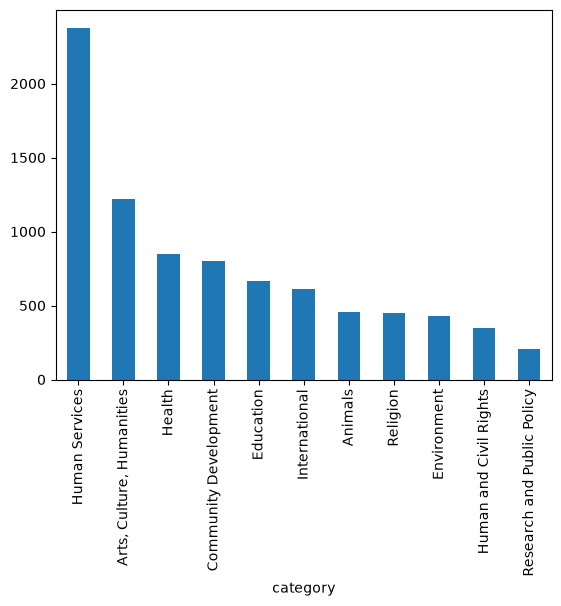

In [6]:
# самый простой график
tab.plot.bar();

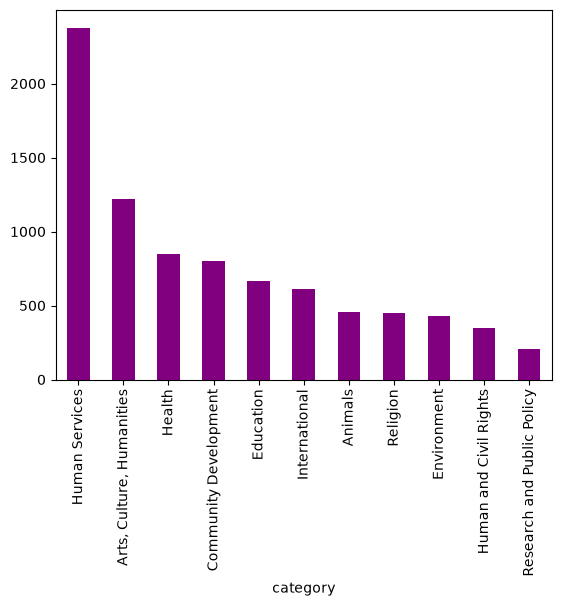

In [7]:
# добавляем цвет
tab.plot.bar(color = "purple");

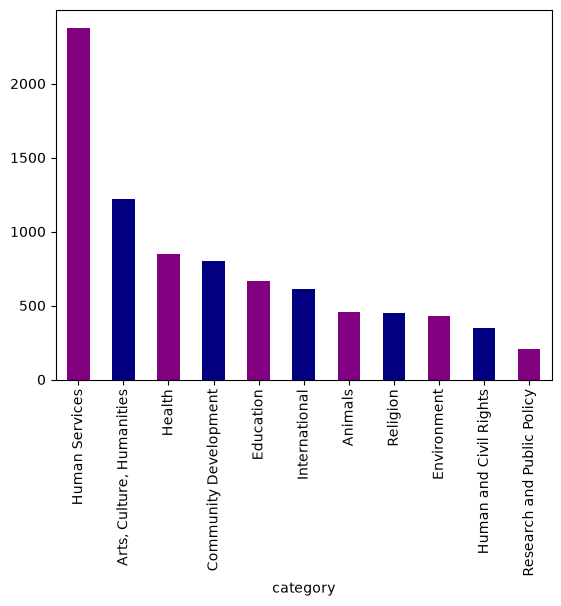

In [8]:
# добавляем чередование цветов, всего столбцов 11
# создаем список из двух цветов, повторяем их 5 раз и доклеиваем еще один цвет

my_colors = ["purple", "navy"] * 5 + ["purple"]
tab.plot.bar(color = my_colors);

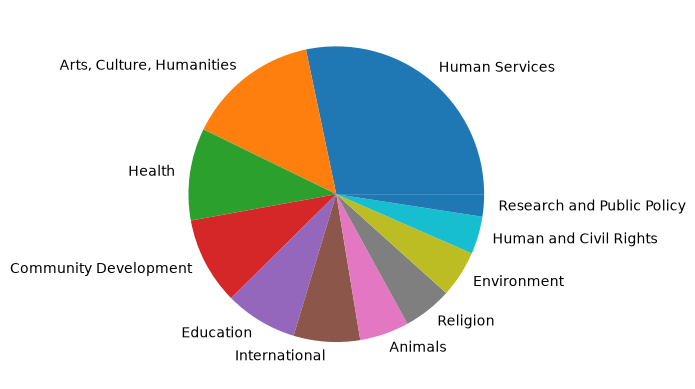

In [9]:
# вот тут проблема – базовая палитра из 10 цветов,
# далее цвета повторяются сначала
# у 11-го сектора цвет такой же, как у 1-ого

tab.plot.pie();

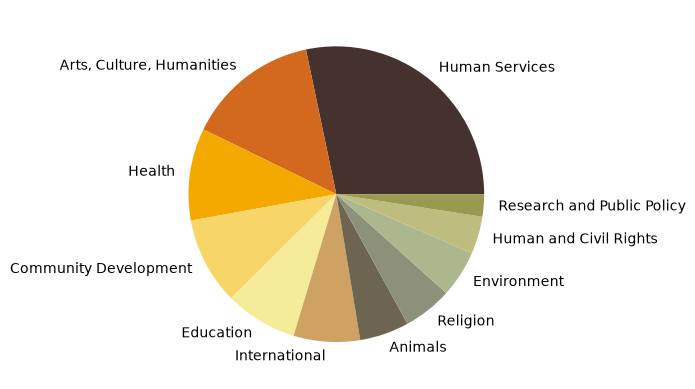

In [10]:
# тут только свою палитру можно взять
# или предварительно схлопнуть все мелкие категории в одну
# у меня при ручном подборе получилась осень на болоте :)

cols = ["#45322E", "#D2691E", "#F4A900", "#F8D568", 
        "#F5EC99", "#CEA262", "#6D6552",  "#8D917A", 
        "#ACB78E",  "#BEBD7F", "#999950"]

tab.plot.pie(colors = cols);

### Задача 3

Постройте, используя возможности `matplotlib`, столбиковую диаграмму для профиля организации.

Подсказка: разделите таблицу частот на индексы (названия категорий) и частоты (высота столбцов на диаграмме) и примените метод `.bar()` к осям `ax`, указав в качестве аргументов названия категорий и высоты столбцов.

In [11]:
names = tab.index
freqs = tab.values

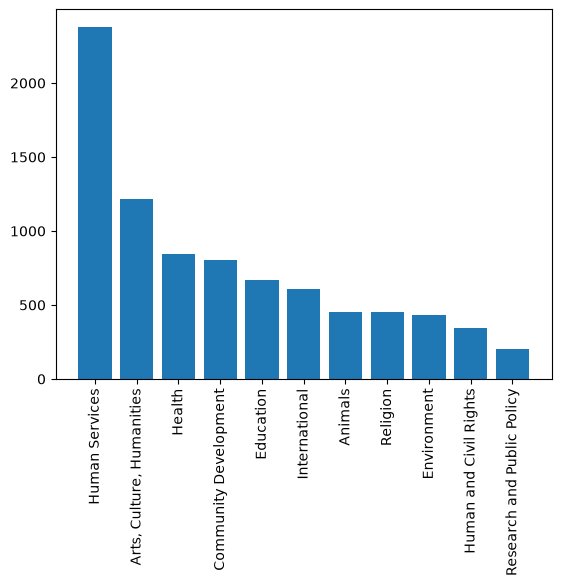

In [12]:
fig, ax = plt.subplots();

# в bar() на первом месте names (категории по оси x)
# на втором месте – частоты freqs (высоты столбцов по оси y)
# поворачиваем подписи по оси x на 90 градусов

ax.bar(names, freqs);
ax.tick_params(axis = 'x', labelrotation = 90)

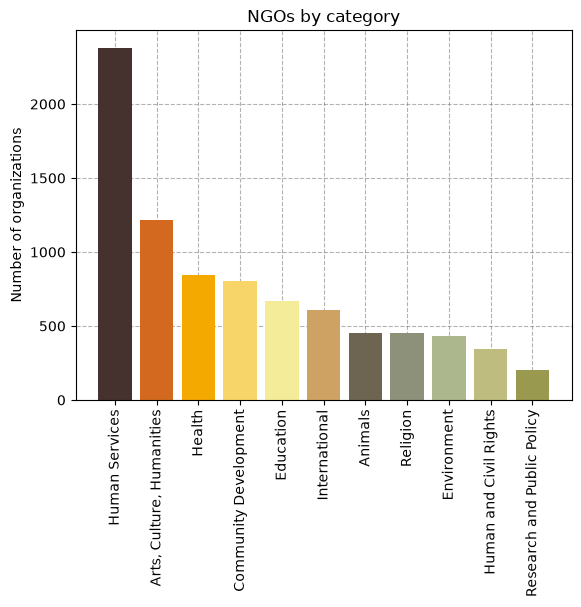

In [13]:
fig, ax = plt.subplots();

# добавляем сетку, убираем ее под график через .set_axisbelow()
# color – цвет сетки, alpha – плотность цвета, linestyle – тип линии

ax.bar(names, freqs, color = cols);
ax.grid(color = "grey", alpha = 0.6, linestyle = "dashed");
ax.set_axisbelow(True);
ax.tick_params(axis = 'x', labelrotation = 90);
ax.set_title("NGOs by category");
ax.set_ylabel("Number of organizations");

Круговую и кольцевую диаграмму построим вместе!

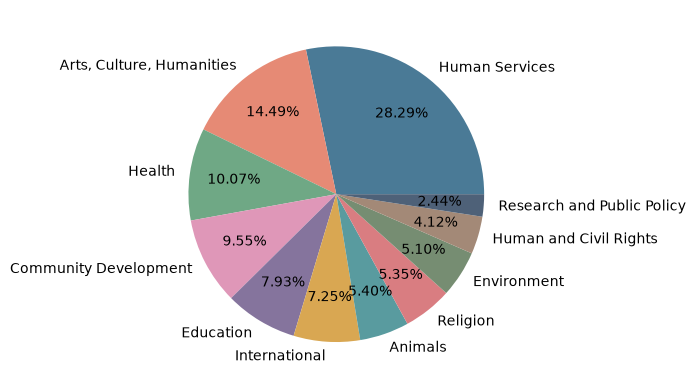

In [14]:
# my_palette – список цветов, поместим ниже в аргумент colors внутри функции pie()

my_palette = ["#4A7A96", "#E68A75", "#6FA885", "#DF97B8", "#85749D", "#D9A752", 
              "#599B9F",  "#D97D81", "#768D72",  "#A38977",  "#4E6178"]

# freqs – частоты, наши основные данные, количество организаций
# labels – подписи секторов, названия категорий names
# autopct – автоматическое добавление подписей с процентами,
# в шаблон подставляем (символ % означает подстановку) дробные числа 
# с точностью до сотых (.2f) и добавляем в конец символ процента 
# (%%, чтобы не путать со спец символом %, здесь такое экранирование)
# pctdistance – расстояние подписей с процентами от центра круга

fig, ax = plt.subplots();
ax.pie(freqs, 
       labels = names, 
       autopct = "%.2f%%", 
       pctdistance = 0.7,
       colors = my_palette)

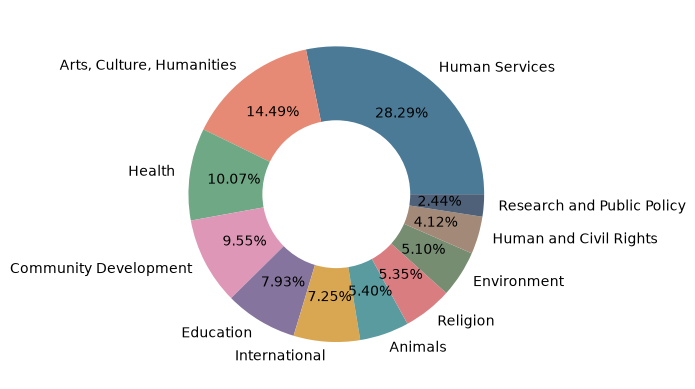

In [15]:
my_palette = ["#4A7A96", "#E68A75", "#6FA885", "#DF97B8", "#85749D", "#D9A752", 
              "#599B9F",  "#D97D81", "#768D72",  "#A38977",  "#4E6178"]

# помещаем в оси круговую диаграмму
# создаем отдельно белый круг с началом в точке (0, 0) радиуса 0.5
# забираем текущее состояние изображения через .gca() – get current axis
# добавляем на него круг через .add_artist()

fig, ax = plt.subplots();

ax.pie(freqs, 
       labels = names, 
       autopct = "%.2f%%", 
       pctdistance = 0.7,
       colors = my_palette)

ci = plt.Circle((0, 0), 0.5, fc = "white")
fig.gca().add_artist(ci);

### Для знатоков Python и любителей эстетики, готовых ради нее нырнуть в диаграмму

**Дополнительно.** Если укрупнять категории нельзя (необходимо видеть все категории подробно) и почему-то нужно оставить кольцевую диаграмму (вообще для большого числа категорий столбиковая диаграмма выглядит приличнее), можно укрупнить сам график + вынести названия категорий в легенду. Шаги:

* в `subplots()` выставляем размер 16 на 9 дюймов, разрешение 300 точек на дюйм;
* в `.pie()` убираем подписи, удаляем `labels = names`;
* к осям `ax` применяем метод `.legend()` и в него заносим подписи `names`.

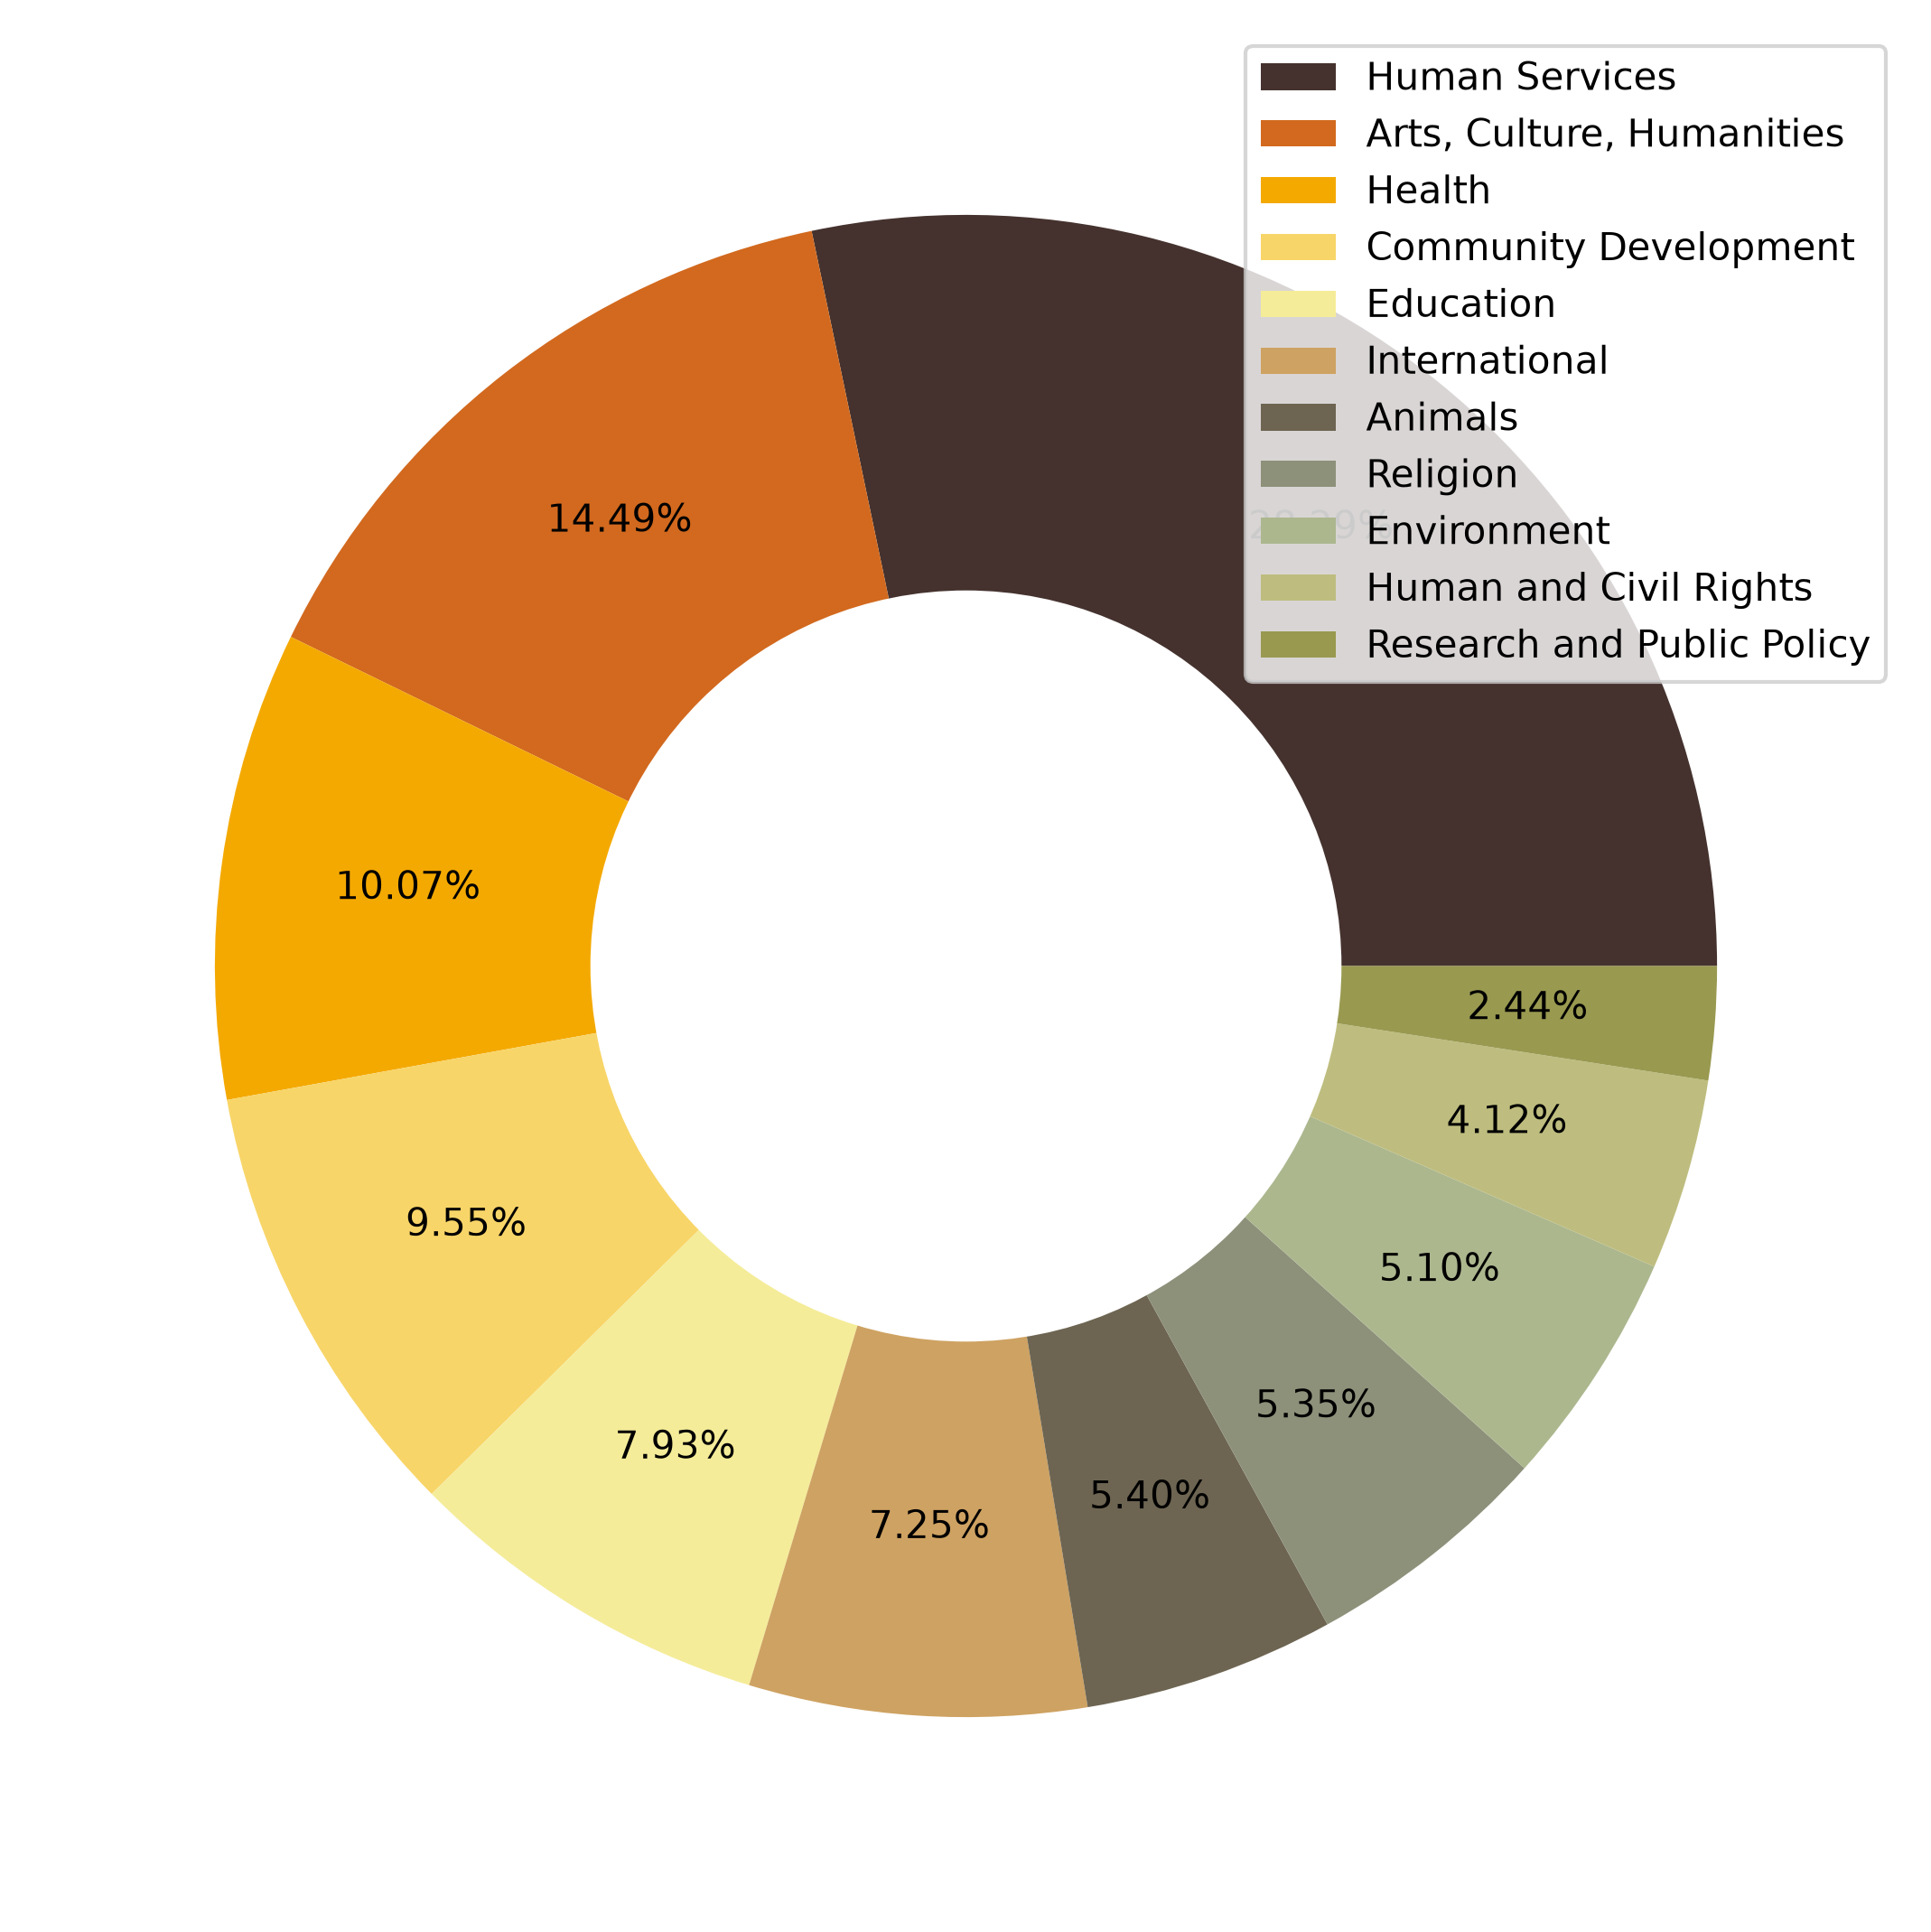

In [16]:
# тут я вернулась к списку цветов cols, 
# хочу показать настройку цвета подписей, нужны темные цвета

fig, ax = plt.subplots(figsize = (16, 9), dpi = 300);

ax.pie(freqs,
       autopct = "%.2f%%", 
       pctdistance = 0.75,
       colors = cols)
ax.legend(names);

ci = plt.Circle((0, 0), 0.5, fc = "white")
fig.gca().add_artist(ci);

Осталось скорректировать положение легенды, чтобы она не перекрывала диаграмму:

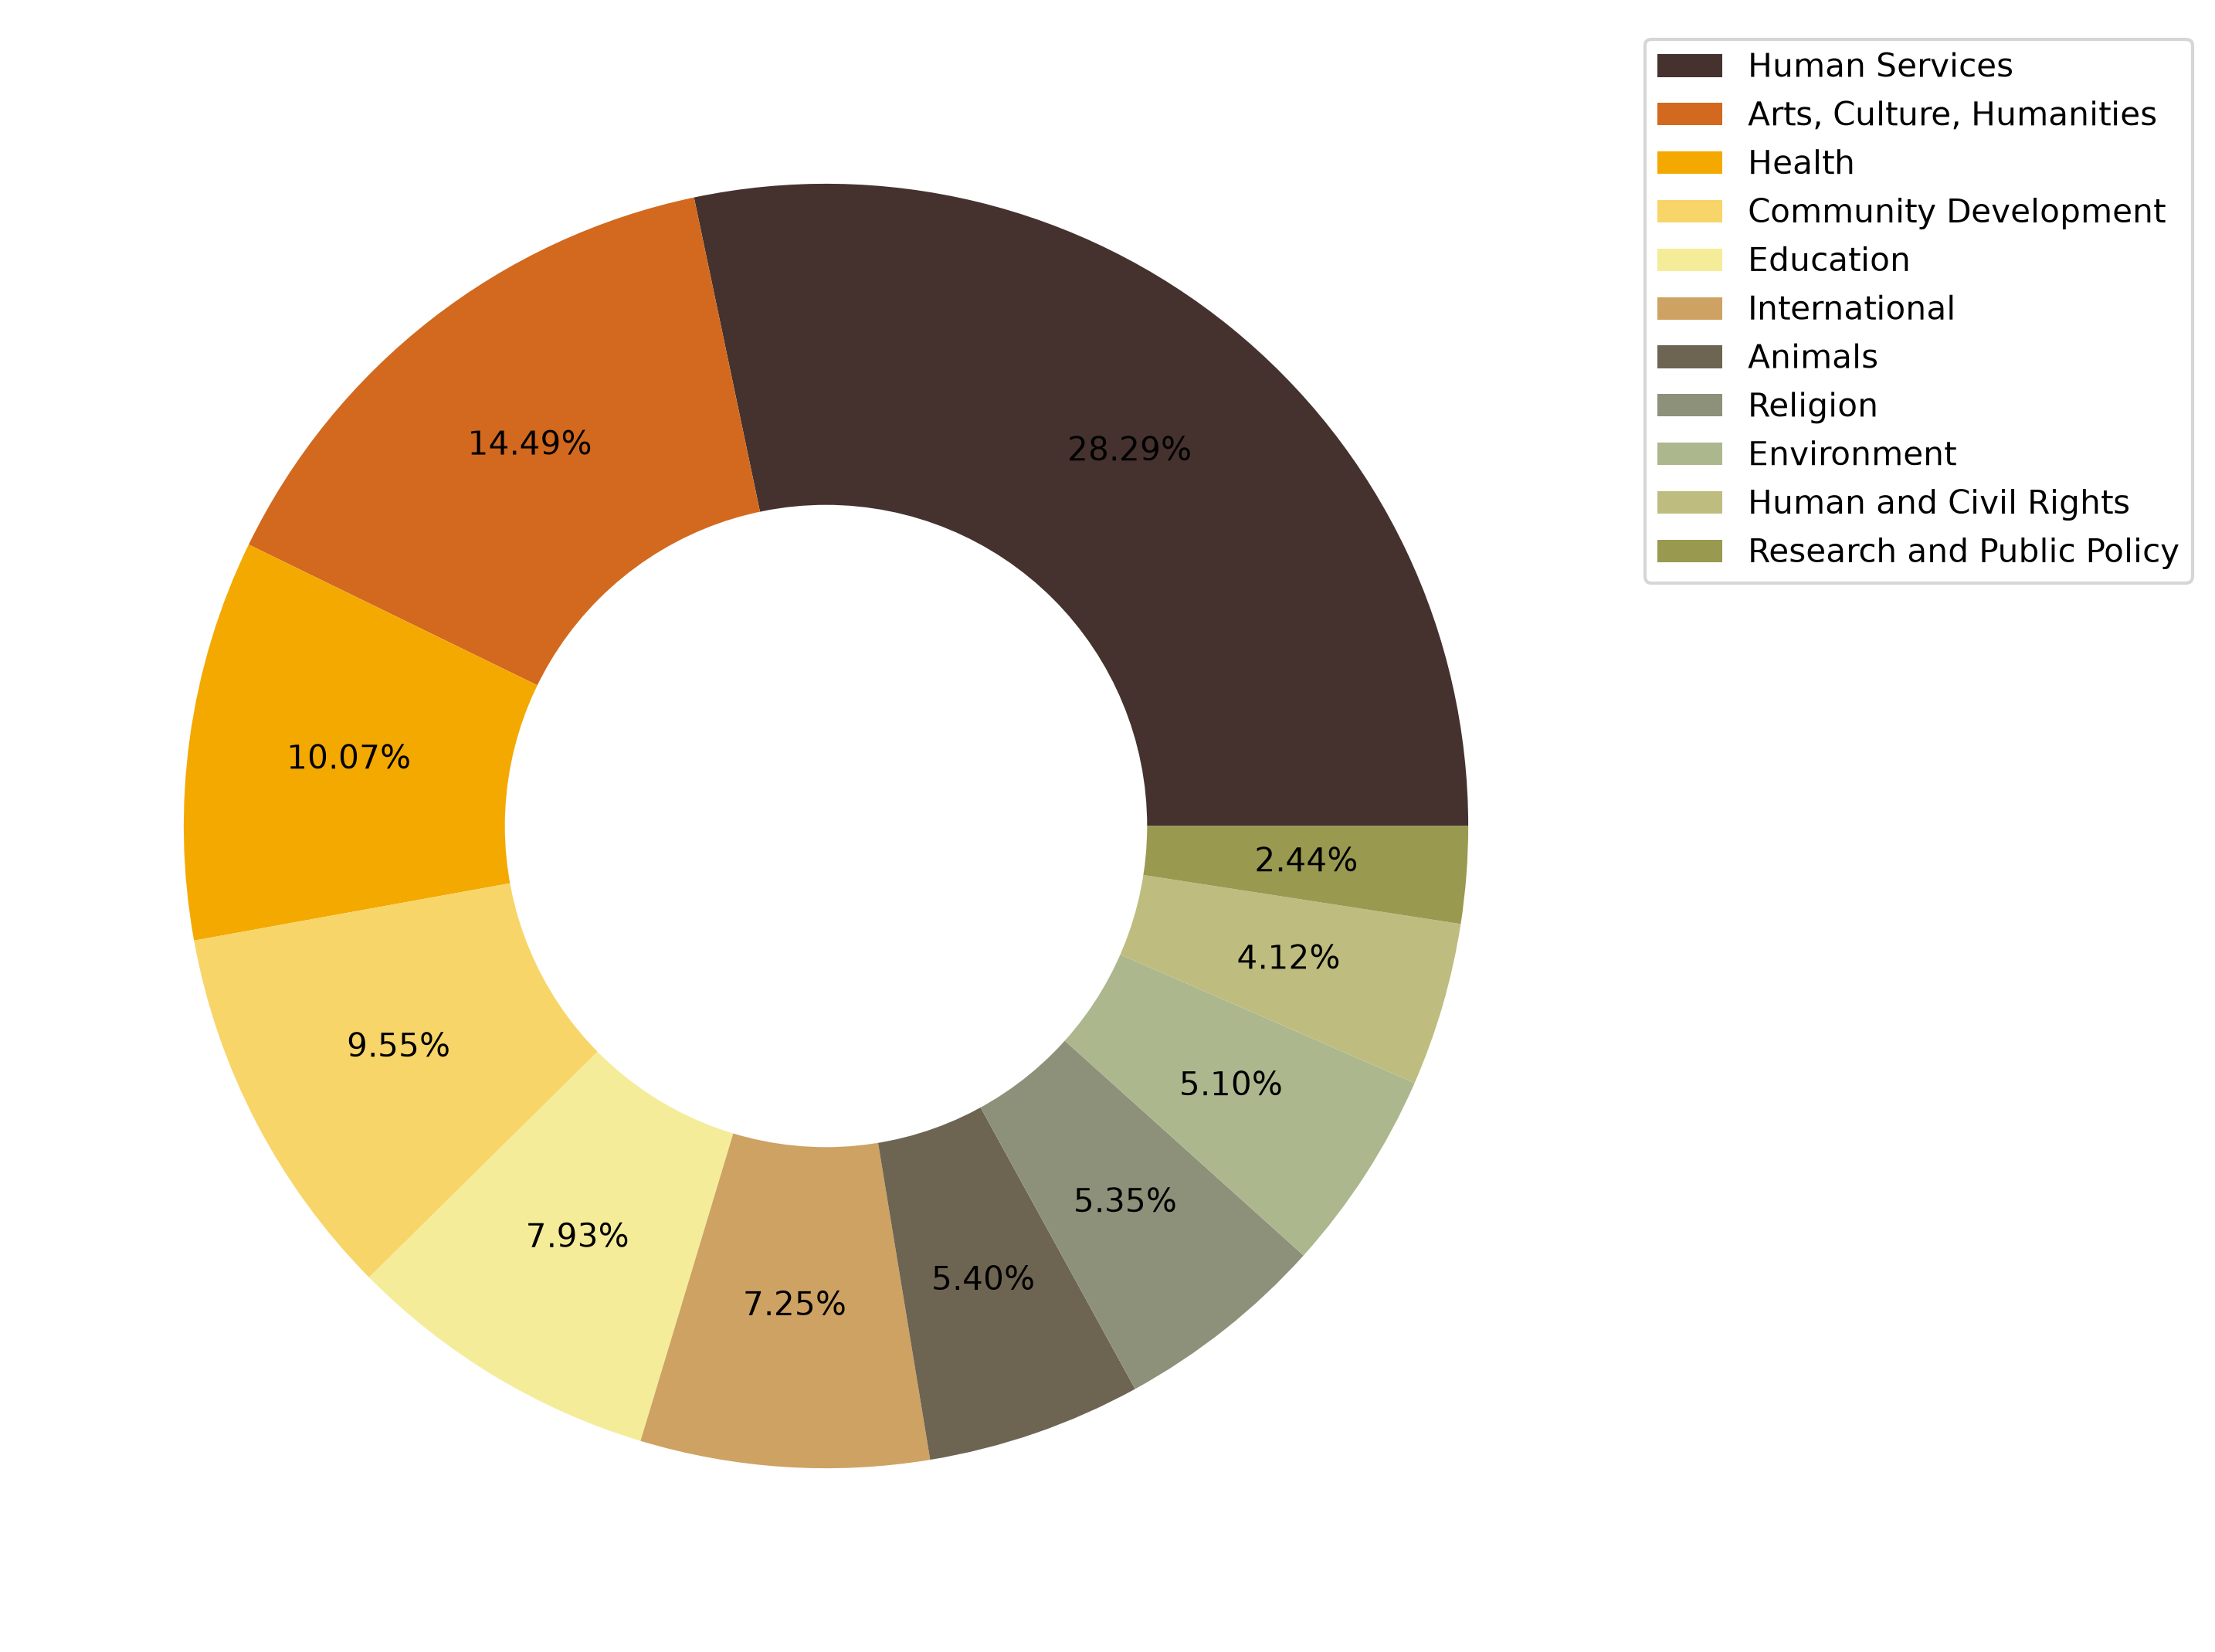

In [17]:
fig, ax = plt.subplots(figsize = (16, 9), dpi = 300);

# bbox_to_anchor() – привязываем легенду к точке (1, 1)
# график по умолчанию от 0 до 1 по обеим осям, поэтому 
# это просто просто правый верхний угол

ax.pie(freqs,
       autopct = "%.2f%%", 
       pctdistance = 0.75,
       colors = cols)
ax.legend(names, bbox_to_anchor = (1, 1));

ci = plt.Circle((0, 0), 0.5, fc = "white")
fig.gca().add_artist(ci);

**Очень дополнительно.** Чтобы настроить цвета подписей с процентами, придется разбирать диаграмму на части! У `pie()` есть аргумент `textprops`, но он поддерживает настройки текста для всей диаграммы сразу. То есть, если мы хотим изменить цвет подписей глобально для всех секторов, например, заменить на белый, это сделать легко:

    ax.pie(freqs, 
      autopct = "%.2f%%", 
      pctdistance = 0.75, 
      colors = cols, 
      textprops = {"color":"white"})

А вот для разных цветов придется осознать, из каких частей состоит круговая диаграмма. Метод `.pie()`, если указан аргумент `autopct` (то есть проценты включены), возвращает три набора – секторы круга, подписи секторов и подписи с процентами. Их можно сохранить в отдельные переменные:

In [19]:
# wedges: сектора, графические объекты типа matplotlib.patches.Wedge 
# texts: подписи с названиями, текстовые объекты Text(), внутри координаты подписи и сама подпись
# autotexts: подписи с процентами, текстовые объекты Text(), внутри координаты подписи и сама подпись
# подписи секторов мы ранее убрали, поэтому в texts на последнем месте пустые строки ''

wedges, texts, autotexts = ax.pie(freqs, autopct = "%.2f%%", 
                                  pctdistance = 0.75, colors = cols)
print(wedges, "\n")
print(texts, "\n")
print(autotexts)

[<matplotlib.patches.Wedge object at 0x156e2f9d0>, <matplotlib.patches.Wedge object at 0x156e2fb10>, <matplotlib.patches.Wedge object at 0x156e2fc50>, <matplotlib.patches.Wedge object at 0x156e2fd90>, <matplotlib.patches.Wedge object at 0x156e2fed0>, <matplotlib.patches.Wedge object at 0x156abc050>, <matplotlib.patches.Wedge object at 0x156abc190>, <matplotlib.patches.Wedge object at 0x156dce990>, <matplotlib.patches.Wedge object at 0x156abc2d0>, <matplotlib.patches.Wedge object at 0x156abc410>, <matplotlib.patches.Wedge object at 0x156abc550>] 

[Text(0.6932953297089839, 0.8540149798473745, ''), Text(-0.6762483587481262, 0.8675760239255496, ''), Text(-1.0896740856799914, 0.15036750645493574, ''), Text(-0.9760069684124206, -0.5073562827150131, ''), Text(-0.5675827856837177, -0.9422578104720126, ''), Text(-0.0714649531289414, -1.0976760726527104, ''), Text(0.35909203526514133, -1.0397369427932908, ''), Text(0.683357038032897, -0.8619879109192343, ''), Text(0.9248735355056317, -0.5954905

Как это можно использовать? Создать список цветов для подписей с процентами `autotexts` и объединить их через `zip()`:

In [20]:
# внутри zip() – пары подпись-цвет

font_cols = ["white", "black", "black", "black", "black", "black", "white", 
           "black", "black", "black", "black"]
print(list(zip(autotexts, font_cols)))

[(Text(0.47270136116521627, 0.5822829408050281, '28.29%'), 'white'), (Text(-0.4610784264191769, 0.5915291072219656, '14.49%'), 'black'), (Text(-0.7429596038727213, 0.10252329985563799, '10.07%'), 'black'), (Text(-0.6654592966448322, -0.34592473821478165, '9.55%'), 'black'), (Text(-0.38698826296617106, -0.6424485071400086, '7.93%'), 'black'), (Text(-0.0487261044060964, -0.7484155040813933, '7.25%'), 'black'), (Text(0.24483547858986907, -0.7089115519045164, '5.40%'), 'white'), (Text(0.46592525320424794, -0.5877190301722052, '5.35%'), 'black'), (Text(0.6305955923902034, -0.406016254425914, '5.10%'), 'black'), (Text(0.7202765294958664, -0.20904956603014113, '4.12%'), 'black'), (Text(0.7478009202365096, -0.057391494957262326, '2.44%'), 'black')]


Остается создать диаграмму как обычно (сохранив ее части в `wedges`, `texts` и `autotexts`), а затем пройтись в цикле по парам «подпись-цвет» и через метод `.set_color()` этот цвет зафиксировать:

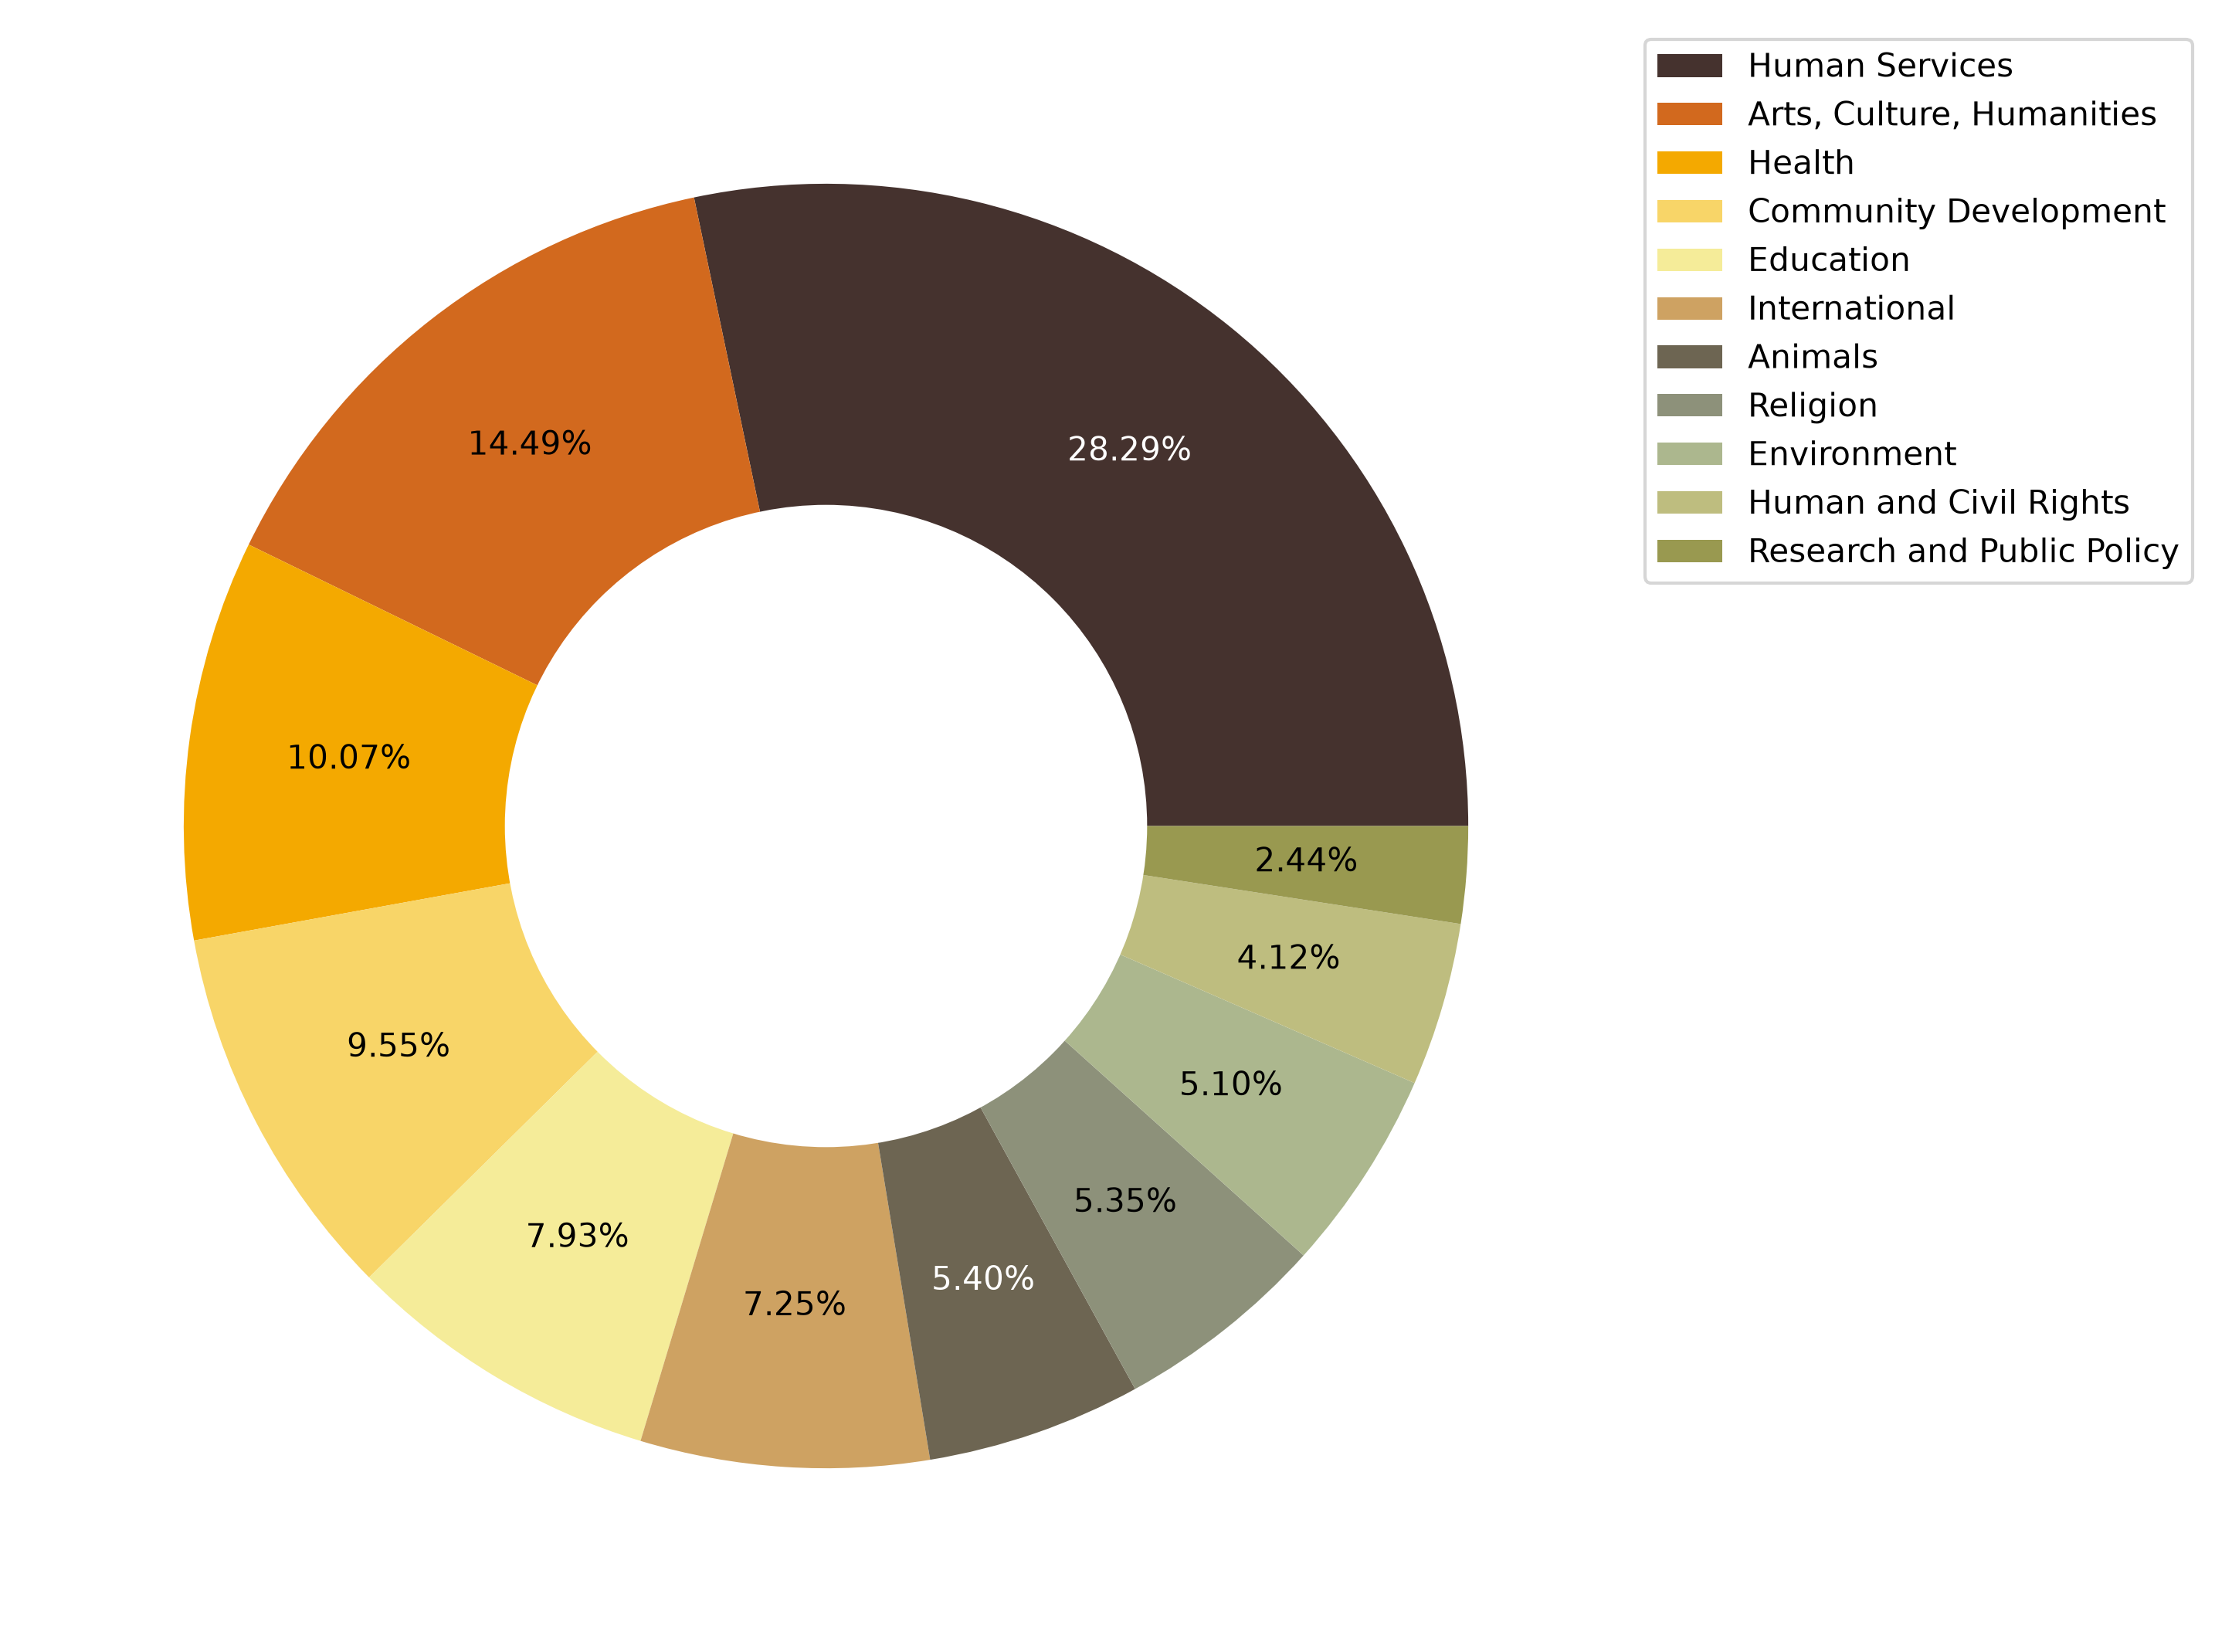

In [21]:
font_cols = ["white", "black", "black", "black", "black", "black", "white", 
           "black", "black", "black", "black"]

fig, ax = plt.subplots(figsize = (16, 9), dpi = 300);
wedges, texts, autotexts = ax.pie(freqs, 
                                  autopct = "%.2f%%", 
                                  pctdistance = 0.75, 
                                  colors = cols)
for atext, col in zip(autotexts, font_cols):
    atext.set_color(col)

ax.legend(names, bbox_to_anchor = (1, 1));

ci = plt.Circle((0, 0), 0.5, fc = "white")
fig.gca().add_artist(ci);

Можно пойти еще дальше и написать код, который будет автоматически определять цвет сектора и если он светлый, выставлять черный цвет подписи, а если темный – белый. Но это уже совсем другая история :) Для интересующихся – почитайте про *Perceived Brightness* (воспринимаемую яркость и ее измерение, там простые формулы, привязанные к формату RGB) и воспользуйтесь тем, что цвет сектора тоже можно забрать.

In [22]:
# например, вот так
# сектора сохранены в wedges
# это цвета в формате виде RGBA
# Red, Green, Blue + непрозрачность Alpha
# интенсивность цвета с делением на 255

for w in wedges:
    print(w.get_facecolor())

(0.27058823529411763, 0.19607843137254902, 0.1803921568627451, 1.0)
(0.8235294117647058, 0.4117647058823529, 0.11764705882352941, 1.0)
(0.9568627450980393, 0.6627450980392157, 0.0, 1.0)
(0.9725490196078431, 0.8352941176470589, 0.40784313725490196, 1.0)
(0.9607843137254902, 0.9254901960784314, 0.6, 1.0)
(0.807843137254902, 0.6352941176470588, 0.3843137254901961, 1.0)
(0.42745098039215684, 0.396078431372549, 0.3215686274509804, 1.0)
(0.5529411764705883, 0.5686274509803921, 0.47843137254901963, 1.0)
(0.6745098039215687, 0.7176470588235294, 0.5568627450980392, 1.0)
(0.7450980392156863, 0.7411764705882353, 0.4980392156862745, 1.0)
(0.6, 0.6, 0.3137254901960784, 1.0)
